In [1]:
#####TASK ONE 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# this is for Make plots look nicer
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Load data
df = pd.read_csv("/Users/kammaniarunsai/Downloads/Data_Feb_2026.csv")

# 2. Basic overview
print("Shape (rows, columns):", df.shape)
print("\nInfo:")
print(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nSummary statistics for numerical columns:")
display(df.describe())

Shape (rows, columns): (1375, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1375 non-null   float64
 1   X2      1375 non-null   float64
 2   X3      1375 non-null   float64
 3   X4      1375 non-null   float64
 4   Label   1374 non-null   float64
dtypes: float64(5)
memory usage: 53.8 KB
None

First 5 rows:


,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0



Summary statistics for numerical columns:


,X1,X2,X3,X4,Label
count,1375.000000,1375.000000,1375.000000,1375.000000,1374.000000
mean,0.386657,2.014202,1.359162,-1.250522,0.443959
std,3.418977,6.676094,4.527056,2.987968,0.497030
min,-70.000000,-13.773100,-50.000000,-80.000000,0.000000
25%,-1.774700,-1.697850,-1.630450,-2.428000,0.000000
50%,0.496650,2.325900,0.616630,-0.586650,0.000000
75%,2.822050,6.819300,3.181600,0.394810,1.000000
max,6.824800,120.000000,17.927400,2.449500,1.000000


In [2]:
# 3. Missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

print("Missing values per column:")
display(missing_df)

# 4. Duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Missing values per column:


,missing_count,missing_percent
Label,1,0.072727
X1,0,0.000000
X2,0,0.000000
X3,0,0.000000
X4,0,0.000000


Number of duplicate rows: 25


In [4]:
# 5. Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# 6. Optionally drop columns with very high missing percentage (e.g. > 40%)
high_missing_cols = missing_df[missing_df["missing_percent"] > 40].index.tolist()
print("Columns with >40% missing (candidate to drop):", high_missing_cols)

df = df.drop(columns=high_missing_cols)

# 7. Impute numerical columns with median (no inplace)
for col in num_cols:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# 8. Impute categorical columns with mode (no inplace)
for col in cat_cols:
    if col in df.columns and df[col].isna().sum() > 0:
        mode_value = df[col].mode().iloc[0]
        df[col] = df[col].fillna(mode_value)

# 9. Recheck missing values
print("Missing values after imputation:")
display(df.isna().sum())

Numerical columns: ['X1', 'X2', 'X3', 'X4', 'Label']
Categorical columns: []
Columns with >40% missing (candidate to drop): []
Missing values after imputation:


X1       0
X2       0
X3       0
X4       0
Label    0
dtype: int64

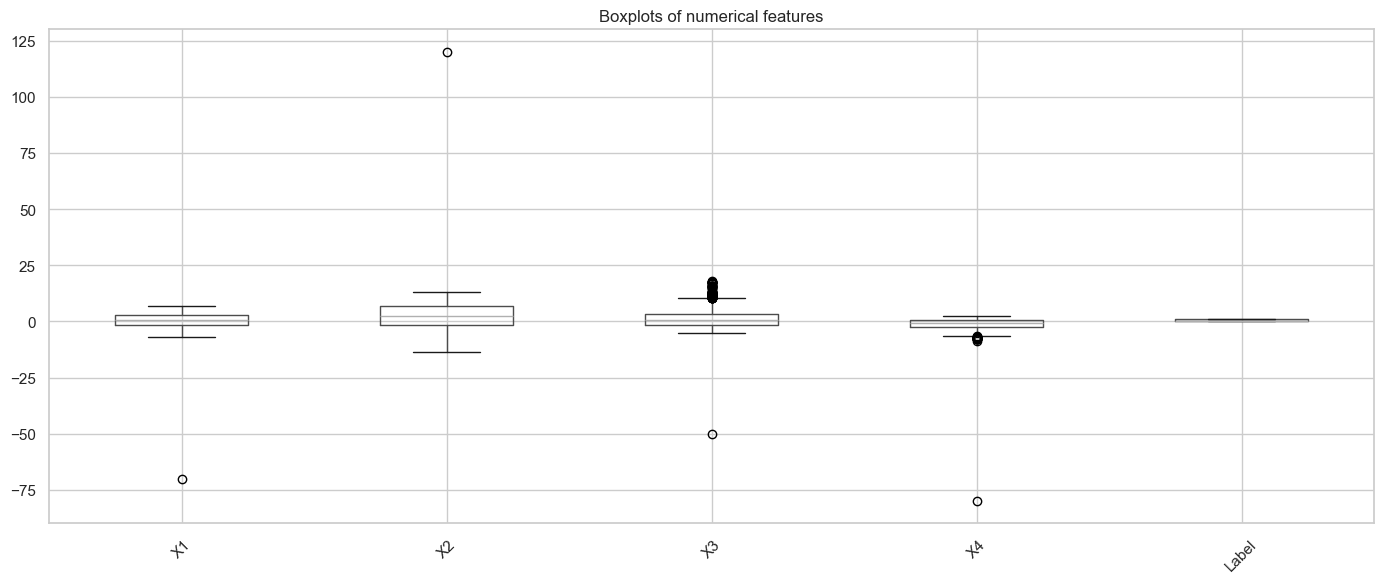

Original shape: (1375, 5)
Shape after outlier removal: (1282, 5)


In [5]:
# 10. Visualise distributions and outliers with boxplots
plt.figure(figsize=(14, 6))
df[num_cols].boxplot(rot=45)
plt.title("Boxplots of numerical features")
plt.tight_layout()
plt.show()

# 11. IQR-based outlier removal function
def remove_outliers_iqr(data, columns, factor=1.5):
    df_clean = data.copy()
    for col in columns:
        if col in df_clean.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - factor * IQR
            upper_bound = Q3 + factor * IQR
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

df_clean = remove_outliers_iqr(df, num_cols)

print("Original shape:", df.shape)
print("Shape after outlier removal:", df_clean.shape)

In [6]:
# 12. Identify categorical columns after cleaning
cat_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns after cleaning:", cat_cols)

# 13. One-hot encode nominal categories
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
display(df_encoded.head())

Categorical columns after cleaning: []
Shape after encoding: (1282, 5)


,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


Summary statistics after cleaning and encoding:


,X1,X2,X3,X4,Label
count,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000
mean,0.736889,2.259628,0.915526,-1.014354,0.418097
std,2.676579,5.324803,3.598097,1.907486,0.493439
min,-7.042100,-10.867900,-5.286100,-6.577500,0.000000
25%,-1.441450,-0.819960,-1.733425,-2.113475,0.000000
50%,0.730060,2.473800,0.484680,-0.496130,0.000000
75%,2.999175,6.771725,2.809300,0.429397,1.000000
max,6.824800,12.951600,10.333200,2.449500,1.000000


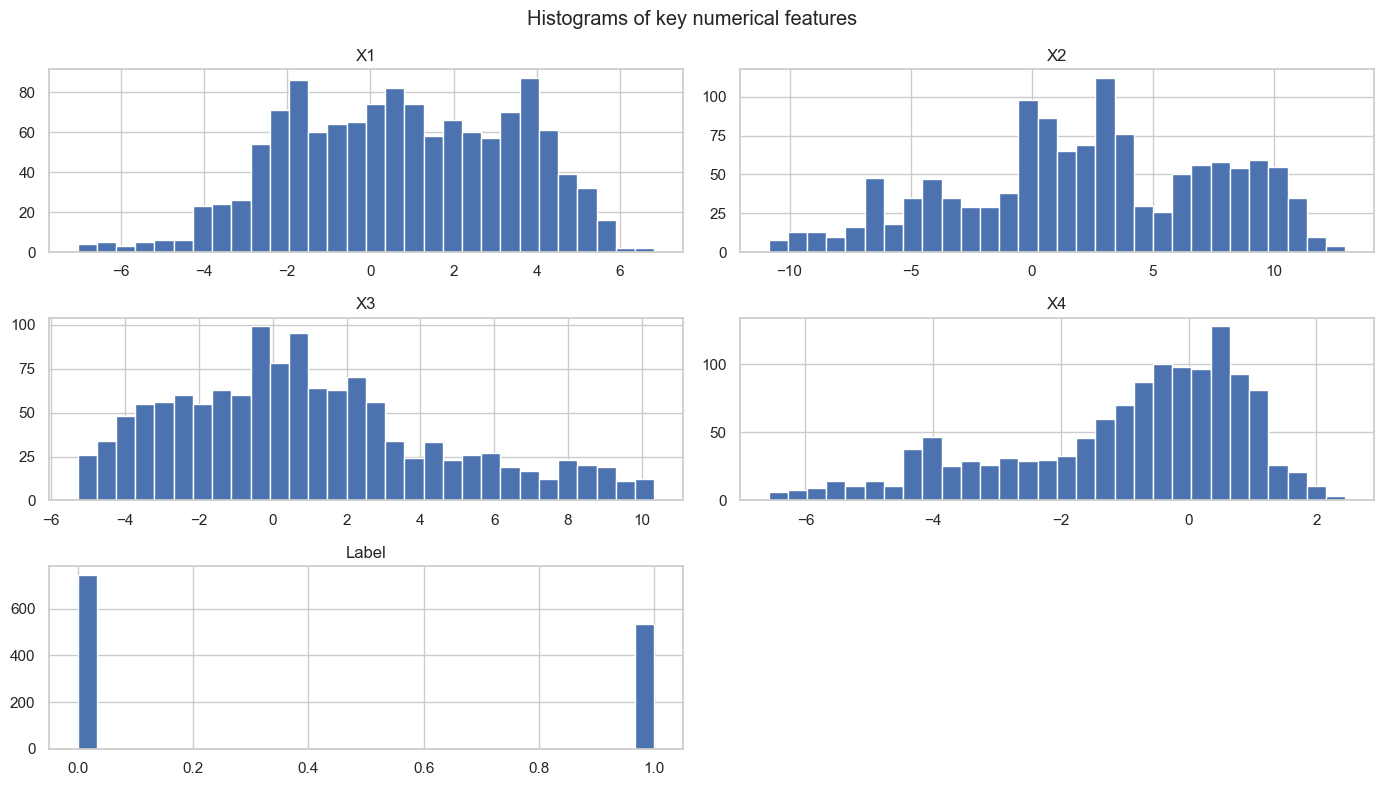

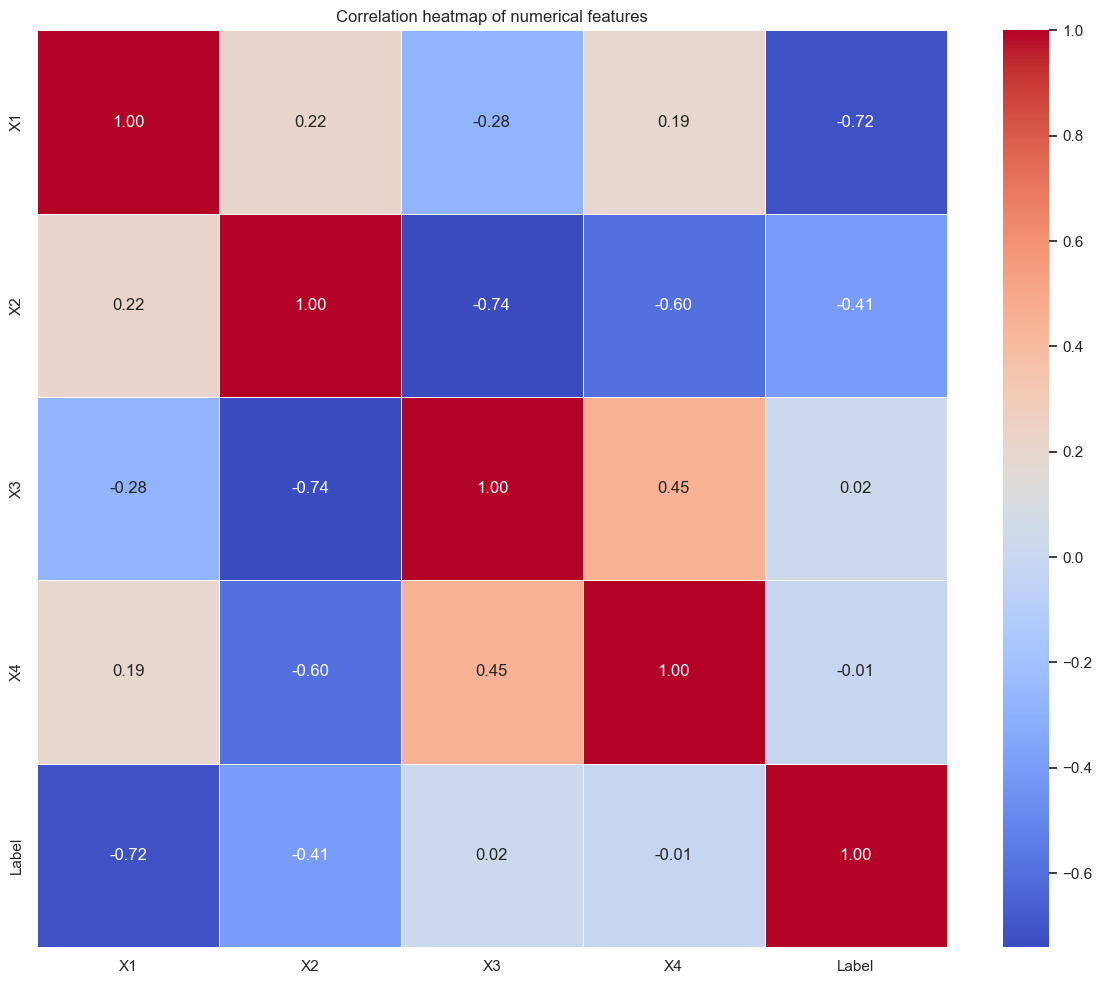

In [8]:
# 14. Descriptive statistics on cleaned data
print("Summary statistics after cleaning and encoding:")
display(df_encoded.describe())

# 15. Histograms for key numerical features
key_num_cols = df_encoded.select_dtypes(include=["int64", "float64"]).columns.tolist()[:6]
df_encoded[key_num_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Histograms of key numerical features")
plt.tight_layout()
plt.show()

# 16. Correlation matrix and heatmap
corr = df_encoded.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5,
    annot=True,      
    fmt=".2f"        
)
plt.title("Correlation heatmap of numerical features")
plt.tight_layout()
plt.show()

In [10]:
###Task 2
from sklearn.model_selection import train_test_split

# Targets 
class_target = "Label"   # classification target column
reg_target   = "X3"      # regression target column

# Features and targets for each task
X_class = df_encoded.drop(columns=[class_target, reg_target])
y_class = df_encoded[class_target]

X_reg = df_encoded.drop(columns=[class_target, reg_target])
y_reg = df_encoded[reg_target]

# 70/30 train–test split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define and train classifier
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

clf.fit(Xc_train, yc_train)

# Predictions
yc_pred = clf.predict(Xc_test)

# Metrics
clf_acc = accuracy_score(yc_test, yc_pred)
print("Random Forest classification accuracy:", clf_acc)

print("\nClassification report:")
print(classification_report(yc_test, yc_pred))

print("\nConfusion matrix:")
print(confusion_matrix(yc_test, yc_pred))

Random Forest classification accuracy: 0.961038961038961

Classification report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97       224
         1.0       0.95      0.96      0.95       161

    accuracy                           0.96       385
   macro avg       0.96      0.96      0.96       385
weighted avg       0.96      0.96      0.96       385


Confusion matrix:
[[216   8]
 [  7 154]]


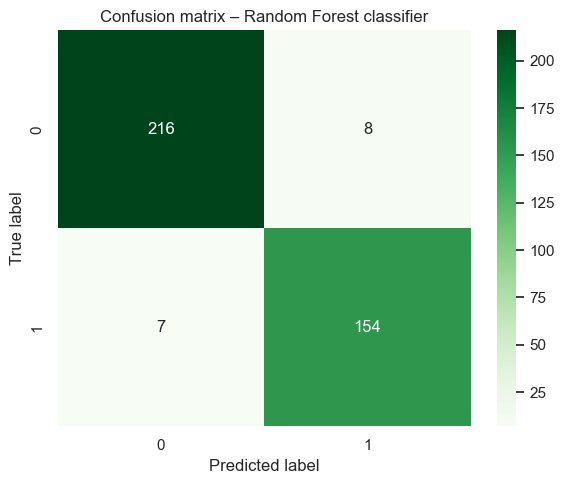

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(yc_test, yc_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix – Random Forest classifier")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define and train KNN regressor
knn_reg = KNeighborsRegressor(
    n_neighbors=5,      
    weights="distance", 
    metric="minkowski"  
)

knn_reg.fit(Xr_train, yr_train)

# Predictions
yr_pred = knn_reg.predict(Xr_test)

# Metrics
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print("KNN regression performance:")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R^2  : {r2:.4f}")

KNN regression performance:
  MSE  : 1.1587
  RMSE : 1.0764
  MAE  : 0.6178
  R^2  : 0.8951


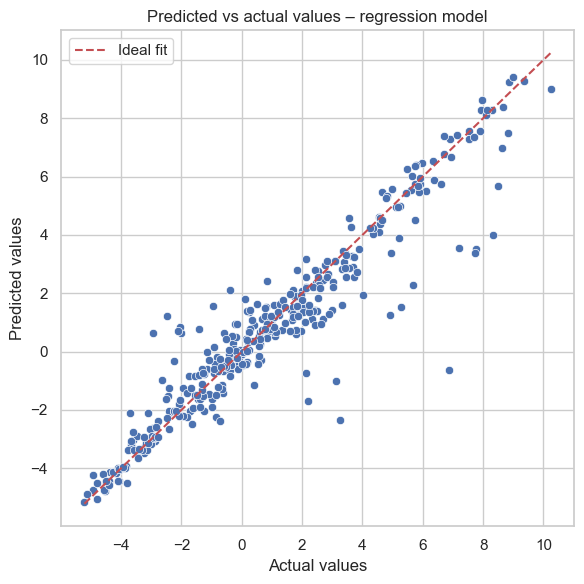

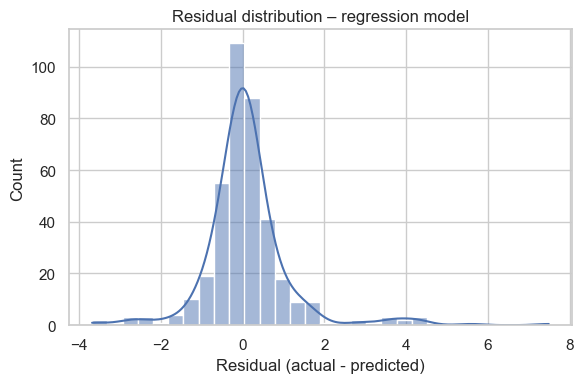

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Predicted vs actual scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=yr_test, y=yr_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs actual values – regression model")
# 45-degree line
min_val = min(yr_test.min(), yr_pred.min())
max_val = max(yr_test.max(), yr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal fit")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Error (residual) distribution
residuals = yr_test - yr_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual (actual - predicted)")
plt.title("Residual distribution – regression model")
plt.tight_layout()
plt.show()

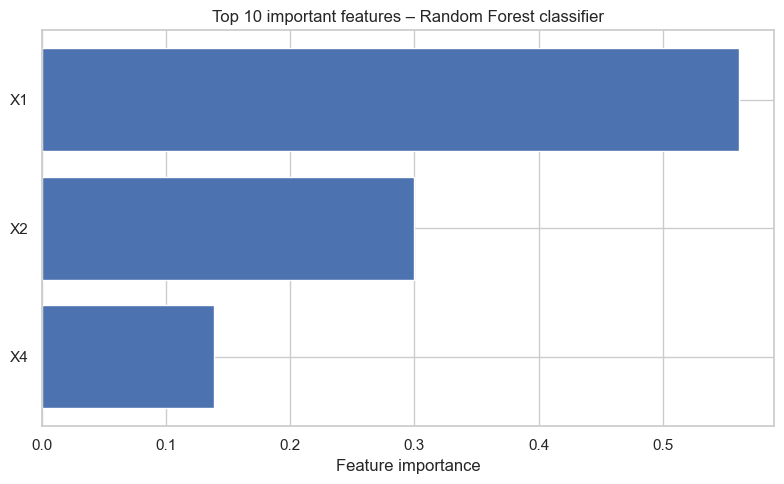

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Feature importances from the trained classifier 'clf'
importances = clf.feature_importances_
feature_names = Xc_train.columns

# Take top 10 most important features
indices = np.argsort(importances)[::-1][:10]
top_features = feature_names[indices]
top_importances = importances[indices]

plt.figure(figsize=(8, 5))
plt.barh(top_features, top_importances)
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Top 10 important features – Random Forest classifier")
plt.tight_layout()
plt.show()